# Linear Regression Model - Draft 1
Quick LR experiment to predict a waste bin's next day fill percentage using table A

In [2]:
from datasets import load_dataset
from sklearn import linear_model
from sklearn.model_selection import train_test_split

dataset = load_dataset("SA61team5/AD-tableA")

print(dataset)

df = dataset["train"].to_pandas()
df.head()

DatasetDict({
    train: Dataset({
        features: ['Index', 'ContainerID', 'Timestamp', 'Fill_percentage', 'Rec', 'Cidx', 'Month', 'Is_weekend', 'Days_since_last_REC', 'Next_day_fill_percentage'],
        num_rows: 27601
    })
})


,Index,ContainerID,Timestamp,Fill_percentage,Rec,Cidx,Month,Is_weekend,Days_since_last_REC,Next_day_fill_percentage
0,0,1000,2021-01-16 13:28:00,52.5,1,0.0,1,1,0,52.5
1,1,1000,2021-01-17 12:34:00,52.5,0,0.0,1,1,1,52.5
2,2,1000,2021-01-18 12:41:00,52.5,0,0.0,1,0,2,52.5
3,3,1000,2021-01-19 12:48:00,52.5,0,0.0,1,0,3,52.5
4,4,1000,2021-01-20 18:27:00,52.5,0,0.0,1,0,4,52.5


In [5]:
#Model Training
x = df[['Fill_percentage','Month','Is_weekend','Days_since_last_REC']]

y = df['Next_day_fill_percentage']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.1, random_state = 42)

# import model
from sklearn.linear_model import LinearRegression

#instantiate
linReg = LinearRegression()

# fit out linear model to the train set data
linReg.fit(x_train, y_train)

#Model Validation

# print the intercept and coefficients
print(linReg.intercept_)
print(linReg.coef_)

from sklearn.metrics import r2_score

y_pred = linReg.predict(x_test) 
print('r2_score: ',r2_score(y_test, y_pred)) 

7.2891682890020135
[0.64853148 0.1018485  3.93539609 0.19075155]
r2_score:  0.4402153679266392


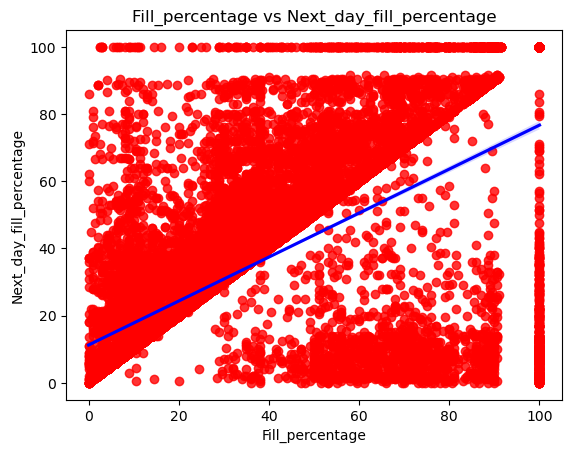

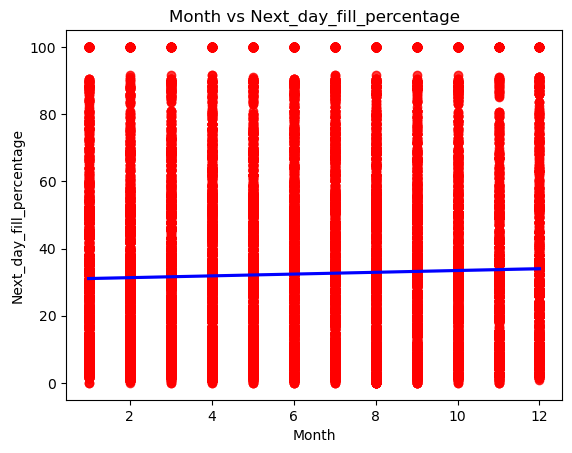

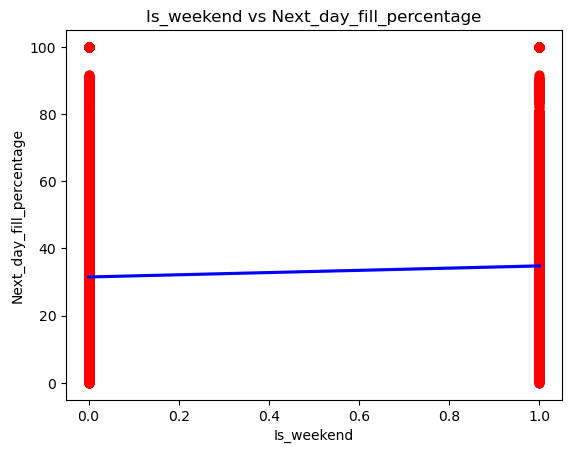

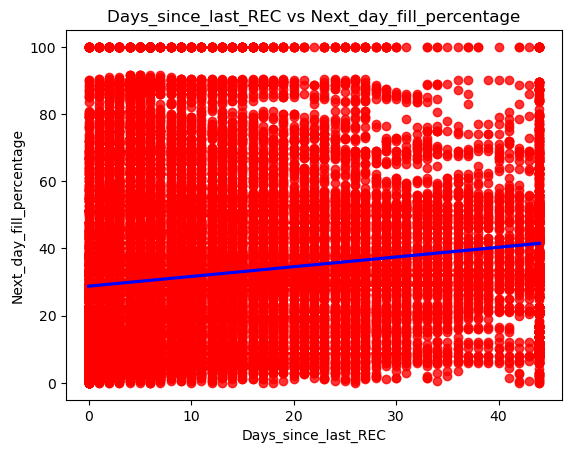

In [7]:
# We want to plot the regression line(blue) vs the actual value(red)
import matplotlib.pyplot as plt
import seaborn as sns

import seaborn as sns
import matplotlib.pyplot as plt

features = [
    'Fill_percentage',
    'Month',
    'Is_weekend',
    'Days_since_last_REC'
]

for feature in features:
    sns.regplot(
        x=feature,
        y='Next_day_fill_percentage',
        data=df,
        line_kws={'color': 'blue'},
        scatter_kws={'color': 'red'}
    )
    plt.title(f'{feature} vs Next_day_fill_percentage')
    plt.show()